In [1]:
import pandas as pd
import numpy as np
file_paths=['0000.parquet','0001.parquet','0002.parquet','0003.parquet','0004.parquet','0005.parquet']
df=pd.read_parquet(file_paths)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10727607 entries, 0 to 10727606
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   videoid     int64 
 1   contentUrl  object
 2   duration    object
 3   page_dir    object
 4   name        object
dtypes: int64(1), object(4)
memory usage: 409.2+ MB


In [3]:
df.describe()

,videoid
count,1.072761e+07
mean,5.798212e+08
std,5.044656e+08
min,1.300000e+01
25%,1.906638e+07
50%,1.010962e+09
75%,1.032311e+09
max,1.067376e+09


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10727607 entries, 0 to 10727606
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   videoid     int64 
 1   contentUrl  object
 2   duration    object
 3   page_dir    object
 4   name        object
dtypes: int64(1), object(4)
memory usage: 409.2+ MB


In [5]:
import matplotlib.pyplot as plt
print(df.isnull().sum())
print(df.duplicated().sum())

videoid       0
contentUrl    0
duration      0
page_dir      0
name          0
dtype: int64
0


In [6]:
pip install isodate

In [7]:
import isodate
def duration_to_seconds(duration):
    if pd.isnull(duration):
        return np.nan
    try:
        parsed_duration = isodate.parse_duration(duration)
        return parsed_duration.total_seconds()
    except Exception as e:
        print(f"Error parsing duration: {duration} - {e}")
        return np.nan
# Apply the function to the 'duration' column
df['duration_seconds'] = df['duration'].apply(duration_to_seconds)

count    1.072761e+07
mean     1.797064e+01
std      2.456413e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.500000e+01
75%      2.200000e+01
max      3.589100e+04
Name: duration_seconds, dtype: float64


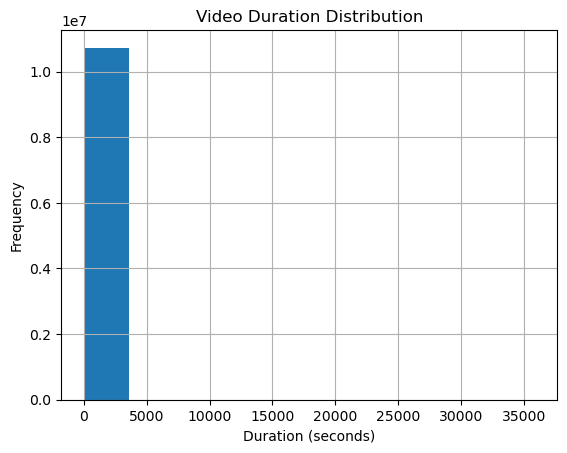

In [8]:
# Descriptive statistics for video duration
print(df['duration_seconds'].describe())
import matplotlib.pyplot as plt
df['duration_seconds'].hist(bins=10)
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Video Duration Distribution')
plt.show()


Most videos are short: The majority of videos fall within the 0-20 second range, indicating a strong skew towards shorter durations.
Few long videos: A small number of videos extend beyond 50 seconds, with very few reaching over 100 seconds.
Right-skewed distribution: The distribution is heavily right-skewed, meaning there are more short videos than long ones.

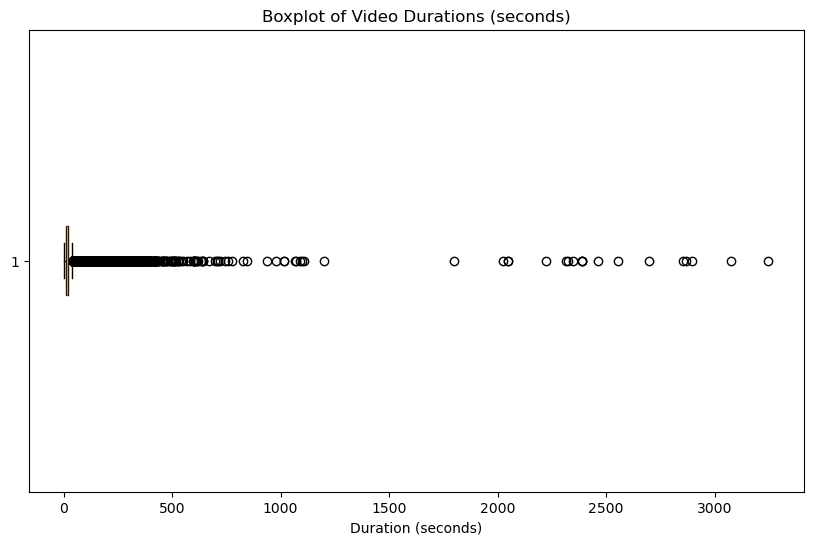

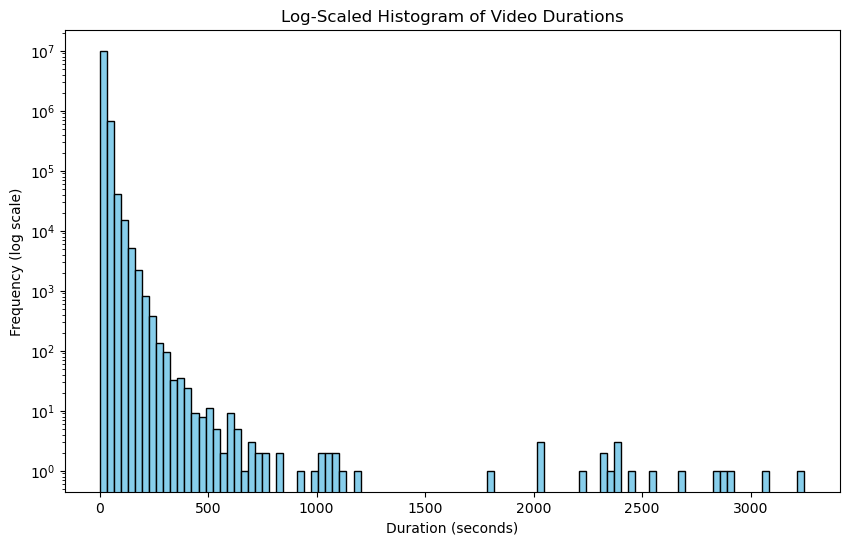

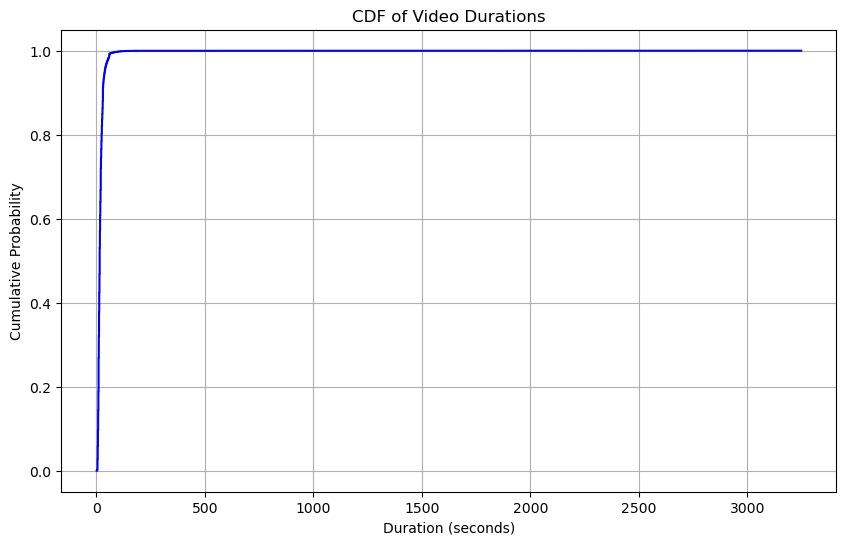

In [23]:
import matplotlib.pyplot as plt
import numpy as np
# Boxplot for duration_seconds
plt.figure(figsize=(10, 6))
plt.boxplot(df['duration_seconds'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title("Boxplot of Video Durations (seconds)")
plt.xlabel("Duration (seconds)")
plt.show()
# Log-scaled histogram
plt.figure(figsize=(10, 6))
plt.hist(df['duration_seconds'], bins=100, log=True, color='skyblue', edgecolor='black')
plt.title("Log-Scaled Histogram of Video Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency (log scale)")
plt.show()
# Cumulative Distribution Function (CDF)
sorted_durations = np.sort(df['duration_seconds'])
cdf = np.arange(1, len(sorted_durations) + 1) / len(sorted_durations)

plt.figure(figsize=(10, 6))
plt.plot(sorted_durations, cdf, color="blue")
plt.title("CDF of Video Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Cumulative Probability")
plt.grid()
plt.show()


Very few long videos: The tail of the distribution beyond 100 seconds is nearly flat, meaning that long videos are rare.
Right-skewed distribution: Similar to the histogram, this confirms that the dataset is dominated by shorter videos.

In [10]:
filtered_df = df[df['duration_seconds'] > 0]
print(filtered_df.shape)  # Verify the number of rows after removal
print(filtered_df['duration_seconds'].describe())  # Summary statistics after removal

(10727337, 6)
count    1.072734e+07
mean     1.797109e+01
std      2.456428e+01
min      1.000000e+00
25%      1.000000e+01
50%      1.500000e+01
75%      2.200000e+01
max      3.589100e+04
Name: duration_seconds, dtype: float64


In [19]:
df=filtered_df[filtered_df['duration_seconds'] < 3500]
df.describe()

,videoid,duration_seconds
count,1.072731e+07,1.072731e+07
mean,5.798180e+08,1.794308e+01
std,5.044655e+08,1.277931e+01
min,1.300000e+01,1.000000e+00
25%,1.906638e+07,1.000000e+01
50%,1.010962e+09,1.500000e+01
75%,1.032310e+09,2.200000e+01
max,1.067376e+09,3.248000e+03


In [12]:
df.head(5)

,videoid,contentUrl,duration,page_dir,name,duration_seconds
0,21179416,https://ak.picdn.net/shutterstock/videos/21179...,PT00H00M11S,006001_006050,Aerial shot winter forest,11.0
1,5629184,https://ak.picdn.net/shutterstock/videos/56291...,PT00H00M29S,071501_071550,Senior couple looking through binoculars on sa...,29.0
2,1063125190,https://ak.picdn.net/shutterstock/videos/10631...,PT00H00M07S,133701_133750,A beautiful cookie with oranges lies on a gree...,7.0
3,1039695998,https://ak.picdn.net/shutterstock/videos/10396...,PT00H00M08S,011901_011950,Japanese highrise office skyscrapers tokyo square,8.0
4,9607838,https://ak.picdn.net/shutterstock/videos/96078...,PT00H00M32S,121551_121600,"Zrenjanin,serbia march 21 2015: fans watching ...",32.0


In [13]:
# Group by 'page_dir' and calculate statistics
duration_by_page = df.groupby('page_dir')['duration_seconds'].describe()
print(duration_by_page)

                count       mean        std  min   25%   50%   75%    max
page_dir                                                                 
000001_000050  4839.0  16.642075  10.082566  3.0  10.0  14.0  20.0   87.0
000051_000100  4374.0  15.915181   8.954666  3.0  10.0  14.0  19.0   99.0
000101_000150  4381.0  17.805296  11.215255  3.0  10.0  15.0  22.0  164.0
000151_000200  2692.0  17.946137  11.822470  3.0  10.0  15.0  22.0  145.0
000201_000250  2886.0  17.760222  11.140042  3.0  10.0  15.0  22.0  117.0
...               ...        ...        ...  ...   ...   ...   ...    ...
199751_199800  3698.0  17.664143  11.497161  1.0  10.0  15.0  21.0  151.0
199801_199850  4207.0  17.617304  11.515706  1.0  10.0  15.0  22.0  133.0
199851_199900  3070.0  17.689251  11.783614  1.0  10.0  15.0  21.0  148.0
199901_199950  2582.0  17.885360  11.969677  2.0  10.0  15.0  21.0  150.0
199951_200000  2115.0  18.055319  12.418943  1.0  10.0  15.0  22.0  162.0

[3590 rows x 8 columns]


In [14]:
unique_page_dir_count = df['page_dir'].nunique()
print(f"Number of unique page directories: {unique_page_dir_count}")

Number of unique page directories: 3590


## Stratified Sampling

In [22]:
sampled_df = df.groupby('page_dir', group_keys=False).apply(lambda x: x.sample(frac=0.5, random_state=42))  # Adjust frac for sample size
print(sampled_df.shape)

(5363658, 6)


C:\Users\harpr\AppData\Local\Temp\ipykernel_23816\2092826442.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('page_dir', group_keys=False).apply(lambda x: x.sample(frac=0.5, random_state=42))  # Adjust frac for sample size


In [16]:
import pandas as pd
import re
import nltk
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# Ensure required nltk resources are downloaded
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)
# Apply preprocessing
sampled_df["cleaned_name"] = sampled_df["name"].astype(str).apply(preprocess)
# Word Frequency Analysis
word_freq = Counter(" ".join(sampled_df["cleaned_name"]).split())
common_words = word_freq.most_common(20)  # Top 20 words
print("Top 20 Most Frequent Words in Descriptions:")
print(common_words)
# TF-IDF Analysis with adjustments
vectorizer = TfidfVectorizer(max_features=20, sublinear_tf=True, smooth_idf=True, min_df=0.01, max_df=0.8)
tfidf_matrix = vectorizer.fit_transform(sampled_df["cleaned_name"])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("\nTF-IDF Scores for Top Words:")
print(tfidf_df.mean().sort_values(ascending=False))  # Average importance of each word


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harpr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\harpr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Top 20 Most Frequent Words in Descriptions:
[('background', 600346), ('view', 527651), ('woman', 468896), ('k', 423140), ('aerial', 397369), ('young', 379484), ('motion', 361260), ('shot', 329371), ('beautiful', 319429), ('man', 303488), ('slow', 278189), ('girl', 274962), ('city', 255236), ('white', 231573), ('video', 230386), ('water', 227910), ('animation', 226402), ('green', 214557), ('hand', 202680), ('close', 200011)]

TF-IDF Scores for Top Words:
background    0.071780
view          0.064620
woman         0.057713
aerial        0.050563
young         0.045332
shot          0.043433
man           0.040793
beautiful     0.039660
motion        0.038513
girl          0.036501
city          0.034716
water         0.030905
video         0.030527
slow          0.030461
animation     0.030446
white         0.029903
green         0.028464
close         0.027279
day           0.026887
hand          0.026555
dtype: float64


In [21]:
scene_keywords = {
    "background": "landscape",
    "view": "landscape",
    "aerial": "landscape",
    "shot": "close-up",
    "motion": "action",
    "slow": "action",
    "animation": "animated",
    "city": "landscape",
    "water": "landscape",
    "woman": "character",
    "man": "character",
    "girl": "character",
    "young": "character",
    "beautiful": "character"
}
def assign_scene_type(text):
    for word, category in scene_keywords.items():
        if word in text:
            return category
    return "other"
sampled_df["scene_type"] = sampled_df["cleaned_name"].apply(assign_scene_type)

KeyError: 'cleaned_name'

In [18]:
stratified_sample = sampled_df.groupby(["page_dir", "scene_type"]).apply(
    lambda x: x.sample(frac=0.5, random_state=42)
).reset_index(drop=True)
print(stratified_sample.shape)

KeyboardInterrupt: 

In [ ]:
important_words = ["smiling", "running", "crying", "laughing", "hugging", "dancing", "fighting", "jumping", "talking"]
def contains_important_words(text):
    return any(word in text for word in important_words)
important_samples = sampled_df[sampled_df["cleaned_name"].apply(contains_important_words)]
# Double the representation of action/emotional scenes in each `page_dir`
oversampled_df = pd.concat([
    sampled_df,
    important_samples.groupby("page_dir").sample(frac=2, replace=True, random_state=42)
])
print(oversampled_df.shape)

In [ ]:
important_words = ["smiling", "running", "crying", "laughing", "hugging", "dancing", "fighting", "jumping", "talking"]
def contains_important_words(text):
    return any(word in text for word in important_words)
important_samples = sampled_df[sampled_df["cleaned_name"].apply(contains_important_words)]
# Double the representation of action/emotional scenes in each `page_dir`
oversampled_df = pd.concat([
    sampled_df,
    important_samples.groupby("page_dir").sample(frac=2, replace=True, random_state=42)
])
print(oversampled_df.shape)

In [ ]:
# Check the most common words across all descriptions
word_freq = Counter(" ".join(sampled_df['cleaned_name']).split())
common_words = word_freq.most_common(20)  # Top 20 most frequent words
print("Top 20 Most Frequent Words in Descriptions:\n", common_words)


In [ ]:
# Calculate the number of unique words in the descriptions
unique_words = set(" ".join(sampled_df['cleaned_name']).split())
print(f"Total unique words: {len(unique_words)}")
# Check the aveage length of descriptions
average_length = sampled_df['cleaned_name'].apply(lambda x: len(x.split())).mean()
print(f"Average description length (in words): {average_length}")


In [ ]:
# Plotting word frequency distribution (Top 50 most frequent words)
import matplotlib.pyplot as plt
# Top 50 most frequent words
common_words = dict(word_freq.most_common(50))
# Plot
plt.figure(figsize=(12,6))
plt.bar(common_words.keys(), common_words.values())
plt.xticks(rotation=90)
plt.title("Top 50 Most Frequent Words in Descriptions")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


In [ ]:
df["unique_word_ratio"] = df["description"].apply(lambda x: len(set(x.split())) / len(x.split()))
print(df["unique_word_ratio"].describe())


In [18]:
sampled_df.head(5)

,videoid,contentUrl,duration,page_dir,name,duration_seconds
52,29269396,https://ak.picdn.net/shutterstock/videos/29269...,PT00H00M15S,000151_000200,Train departs from station. little curious boy...,15.0
1271,15791032,https://ak.picdn.net/shutterstock/videos/15791...,PT00H00M14S,000201_000250,A young woman with a little girl on the beach ...,14.0
1883,28131931,https://ak.picdn.net/shutterstock/videos/28131...,PT00H00M39S,000401_000450,"Young, lost man with tablet looking for direct...",39.0
1041,16945534,https://ak.picdn.net/shutterstock/videos/16945...,PT00H00M15S,001701_001750,Pineapple falls on table breaking in two cuts ...,15.0
799,3365243,https://ak.picdn.net/shutterstock/videos/33652...,PT00H00M27S,003251_003300,Navy destroyer docked off key west florida til...,27.0


# Checking Words with highest frequency

In [36]:
import pandas as pd
import re
import nltk
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from collections import Counter
# Ensure stopwords are downloaded
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
sampled_df["cleaned_name"] = sampled_df["name"].astype(str).apply(preprocess)
# Word Frequency Analysis
word_freq = Counter(" ".join(sampled_df["cleaned_name"]).split())
common_words = word_freq.most_common(20)  # Top 20 words
print("Top 20 Most Frequent Words in Descriptions:")
print(common_words)
# TF-IDF Analysis
vectorizer = TfidfVectorizer(max_features=20)  # Top 20 features
tfidf_matrix = vectorizer.fit_transform(sampled_df["cleaned_name"])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("\nTF-IDF Scores for Top Words:")
print(tfidf_df.mean().sort_values(ascending=False))  # Average importance of each word

Top 20 Most Frequent Words in Descriptions:
[('background', 549), ('view', 465), ('k', 380), ('motion', 362), ('aerial', 355), ('woman', 351), ('young', 319), ('man', 293), ('beautiful', 288), ('shot', 285), ('slow', 260), ('white', 234), ('city', 225), ('girl', 220), ('green', 207), ('animation', 181), ('day', 179), ('water', 179), ('red', 177), ('concept', 177)]

TF-IDF Scores for Top Words:
background    0.070613
view          0.063067
aerial        0.050559
woman         0.049276
man           0.043932
young         0.042676
shot          0.042390
motion        0.042369
beautiful     0.039310
city          0.034292
white         0.033549
girl          0.031845
slow          0.031671
green         0.029476
day           0.027725
animation     0.026601
water         0.026196
concept       0.025939
red           0.025862
blue          0.025499
dtype: float64


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harpr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
page_dir_counts = sampled_df['page_dir'].nunique()
print("\nPage Directory Counts:\n", page_dir_counts)


Page Directory Counts:
 2646


In [31]:
page_dir_counts = sampled_df['page_dir'].value_counts()
most_rows_page_dir = page_dir_counts.idxmax()
most_rows_count = page_dir_counts.max()
print(f"The page directory with the most rows is: {most_rows_page_dir} with {most_rows_count} rows.")


The page directory with the most rows is: 074151_074200 with 5 rows.


In [37]:
sampled_df.columns

Index(['videoid', 'contentUrl', 'duration', 'page_dir', 'name',
       'duration_seconds', 'cleaned_name'],
      dtype='object')

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=10)  # Limit to 10 most important words
X = vectorizer.fit_transform(sampled_df["cleaned_name"])
top_words = vectorizer.get_feature_names_out()
word_scores = X.sum(axis=0).A1 
word_score_dict = dict(zip(top_words, word_scores))
sorted_word_score = sorted(word_score_dict.items(), key=lambda x: x[1], reverse=True)
most_relevant_word = sorted_word_score[0][0]
print(f"Most relevant one-word project directory name: {most_relevant_word}")

Most relevant one-word project directory name: background


In [39]:
def most_common_word(group):
    text = " ".join(group["cleaned_name"])
    word_freq = Counter(text.split())
    return word_freq.most_common(1)[0][0] 
common_words_per_page_dir = sampled_df.groupby('page_dir').apply(most_common_word)
print("\nMost Common Word in Each Project Directory:")
print(common_words_per_page_dir)


Most Common Word in Each Project Directory:
page_dir
000001_000050           fiery
000051_000100            game
000101_000150         closeup
000151_000200           train
000201_000250           sanya
                     ...     
199601_199650           shock
199701_199750     intelligent
199801_199850    strawberries
199851_199900        abstract
199901_199950            aden
Length: 2646, dtype: object


C:\Users\harpr\AppData\Local\Temp\ipykernel_34176\2346884711.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  common_words_per_page_dir = sampled_df.groupby('page_dir').apply(most_common_word)


In [1]:
sampled_df['page_dir'].value_counts().plot(kind='bar')


NameError: name 'sampled_df' is not defined

: 